<a href="https://colab.research.google.com/github/Jacquesluz97/Fontes-de-informa-es-e-banco-de-dados/blob/main/DADOS-CONSUMO-CERVEJA-EM-SP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dongeorge/beer-consumption-sao-paulo")

print("Path to dataset files:", path)

100%|██████████| 5.24k/5.24k [00:00<00:00, 11.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/dongeorge/beer-consumption-sao-paulo/versions/2


In [2]:
import pandas as pd
import os

# List files in the downloaded dataset directory
print("Files in the dataset directory:")
for file in os.listdir(path):
    print(file)

Files in the dataset directory:
Consumo_cerveja.csv


In [4]:
# Assuming the CSV file is named 'Consumo_cerveja.csv'
csv_file_path = os.path.join(path, 'Consumo_cerveja.csv')

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head(10))

,Data,Temperatura Media (C),Temperatura Minima (C),Temperatura Maxima (C),Precipitacao (mm),Final de Semana,Consumo de cerveja (litros)
0,2015-01-01,"27,3","23,9","32,5",0,0.0,25.461
1,2015-01-02,"27,02","24,5","33,5",0,0.0,28.972
2,2015-01-03,"24,82","22,4","29,9",0,1.0,30.814
3,2015-01-04,"23,98","21,5","28,6","1,2",1.0,29.799
4,2015-01-05,"23,82",21,"28,3",0,0.0,28.900
5,2015-01-06,"23,78","20,1","30,5","12,2",0.0,28.218
6,2015-01-07,24,"19,5","33,7",0,0.0,29.732
7,2015-01-08,"24,9","19,5","32,8","48,6",0.0,28.397
8,2015-01-09,"28,2","21,9",34,"4,4",0.0,24.886
9,2015-01-10,"26,76","22,1","34,2",0,1.0,37.937


In [5]:
# Convert columns with comma decimal separator to numeric
for col in ['Temperatura Media (C)', 'Temperatura Minima (C)', 'Temperatura Maxima (C)', 'Precipitacao (mm)']:
    if col in df.columns:
        df[col] = df[col].str.replace(',', '.', regex=False).astype(float)

# Convert 'Data' column to datetime objects
df['Data'] = pd.to_datetime(df['Data'])

# Display the DataFrame info to check data types after conversion
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 941 entries, 0 to 940
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Data                         365 non-null    datetime64[ns]
 1   Temperatura Media (C)        365 non-null    float64       
 2   Temperatura Minima (C)       365 non-null    float64       
 3   Temperatura Maxima (C)       365 non-null    float64       
 4   Precipitacao (mm)            365 non-null    float64       
 5   Final de Semana              365 non-null    float64       
 6   Consumo de cerveja (litros)  365 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 51.6 KB


In [6]:
# Drop rows with any missing values
df_cleaned = df.dropna()

print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape: {df_cleaned.shape}")

Original DataFrame shape: (941, 7)
Cleaned DataFrame shape: (365, 7)


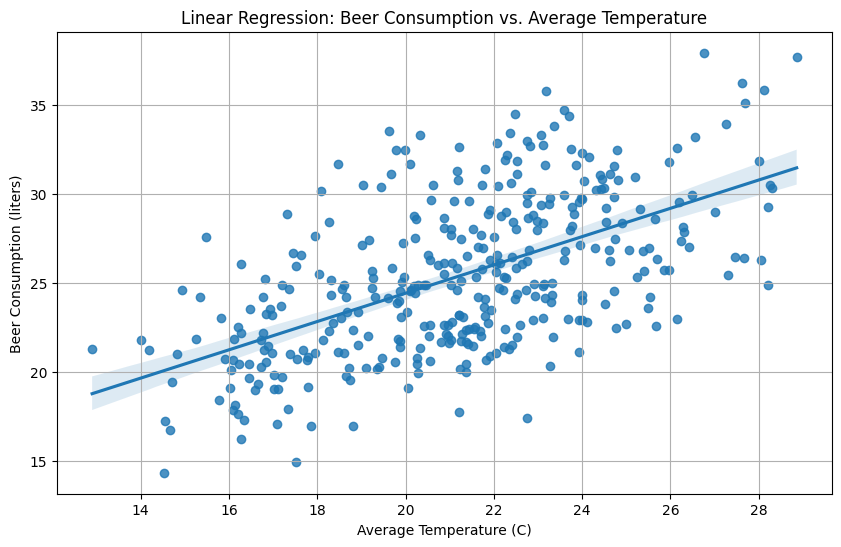

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a linear regression plot
plt.figure(figsize=(10, 6))
sns.regplot(x='Temperatura Media (C)', y='Consumo de cerveja (litros)', data=df_cleaned)
plt.title('Linear Regression: Beer Consumption vs. Average Temperature')
plt.xlabel('Average Temperature (C)')
plt.ylabel('Beer Consumption (liters)')
plt.grid(True)
plt.show()

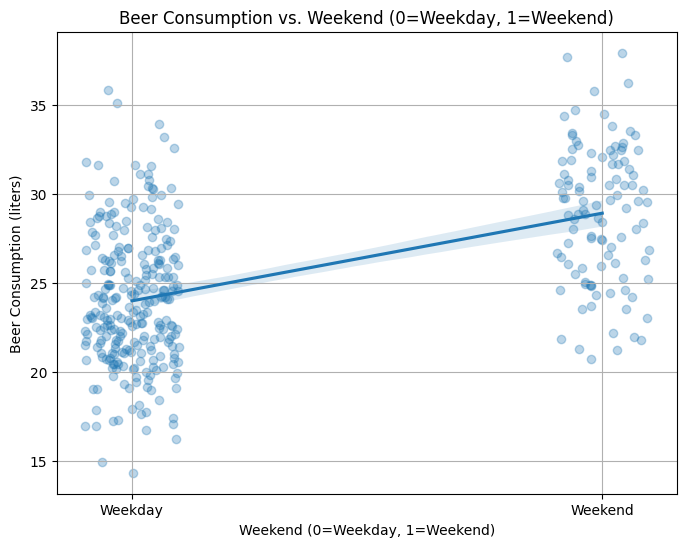

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot with 'Final de Semana' on the x-axis
plt.figure(figsize=(8, 6))
sns.regplot(x='Final de Semana', y='Consumo de cerveja (litros)', data=df_cleaned, x_jitter=0.1, scatter_kws={'alpha':0.3})
plt.title('Beer Consumption vs. Weekend (0=Weekday, 1=Weekend)')
plt.xlabel('Weekend (0=Weekday, 1=Weekend)')
plt.ylabel('Beer Consumption (liters)')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.grid(True)
plt.show()

In [8]:
# Calculate the correlation between 'Temperatura Media (C)' and 'Consumo de cerveja (litros)'
correlation = df_cleaned['Temperatura Media (C)'].corr(df_cleaned['Consumo de cerveja (litros)'])

print(f"Correlation between Average Temperature and Beer Consumption: {correlation:.2f}")

Correlation between Average Temperature and Beer Consumption: 0.57
